# SPANet loss scan diagnostics

This notebook reads TensorBoard event files for the current SPANet runs and compares:
- branch assignment losses
- branch detection losses
- total loss
- validation metrics
- automatic loss-balance weights when available

Designed to run on manivald, reading directly from `/local/norman/UHHAnalysis/SPANet/outputs`.

In [1]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

USER_OUTPUT_BASE = None
candidate_bases = [
    Path('/local/norman/UHHAnalysis/SPANet/outputs'),
    Path('/home/norman/manivald-home/SPANet/outputs'),
]

if USER_OUTPUT_BASE is not None:
    OUTPUT_BASE = Path(USER_OUTPUT_BASE).expanduser().resolve()
else:
    OUTPUT_BASE = None
    for candidate in candidate_bases:
        if candidate.exists():
            OUTPUT_BASE = candidate
            break
    if OUTPUT_BASE is None:
        raise FileNotFoundError('Could not find SPANet outputs base directory. Set USER_OUTPUT_BASE manually.')

print(f'Using OUTPUT_BASE = {OUTPUT_BASE}')

RUNS = {
    'baseline_5f_balanced': '260706_SPANet_22v1_anygpu',
    'hh_only_5f': '260917_spanet_hh_only_5features_unique',
    'no_balance': '260731_spanet_lossscan_nobalance',
    'hh_assign_1p25': '260803_spanet_lossscan_hhassign125_fp32',
    'hh_assign_1p50': '260805_spanet_lossscan_hhassign150_fp32',
    'pcgrad_5f_old': '260921_spanet_pcgrad_5features_resume',
    'pcgrad_5f_v2': '260928_spanet_pcgrad_5features_v2_resume',
    'pcgrad_global_5f': '261001_spanet_pcgrad_global_5features',
}


Using OUTPUT_BASE = /local/norman/UHHAnalysis/SPANet/outputs


In [2]:
def find_event_file(run_dir):
    version_dir = run_dir / 'version_0'
    files = sorted(version_dir.glob('events.out.tfevents.*'))
    if not files:
        raise FileNotFoundError(f'No TensorBoard event file found in {version_dir}')
    return files[-1]

def load_event_accumulator(event_file):
    ea = EventAccumulator(str(event_file), size_guidance={'scalars': 0})
    ea.Reload()
    return ea

def scalar_df(ea, tag, run_label):
    events = ea.Scalars(tag)
    return pd.DataFrame({
        'wall_time': [e.wall_time for e in events],
        'step': [e.step for e in events],
        'value': [e.value for e in events],
        'tag': tag,
        'run': run_label,
    })

def smooth_series(values, alpha=0.15):
    out = []
    prev = None
    for x in values:
        prev = x if prev is None else alpha * x + (1 - alpha) * prev
        out.append(prev)
    return np.asarray(out)

event_files = {}
accumulators = {}
for label, run_name in RUNS.items():
    run_dir = OUTPUT_BASE / run_name
    event_files[label] = find_event_file(run_dir)
    accumulators[label] = load_event_accumulator(event_files[label])

pd.DataFrame([{
    'run': label,
    'run_dir': str((OUTPUT_BASE / RUNS[label]).resolve()),
    'event_file': str(event_files[label]),
} for label in RUNS])


2026-10-01 10:21:15.994333: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/conda/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


,run,run_dir,event_file
0,baseline_5f_balanced,/local/norman/UHHAnalysis/SPANet/outputs/26070...,/local/norman/UHHAnalysis/SPANet/outputs/26070...
1,no_balance,/local/norman/UHHAnalysis/SPANet/outputs/26073...,/local/norman/UHHAnalysis/SPANet/outputs/26073...
2,hh_assign_1p25,/local/norman/UHHAnalysis/SPANet/outputs/26080...,/local/norman/UHHAnalysis/SPANet/outputs/26080...
3,hh_assign_1p50,/local/norman/UHHAnalysis/SPANet/outputs/26080...,/local/norman/UHHAnalysis/SPANet/outputs/26080...
4,pcgrad_5f_old,/local/norman/UHHAnalysis/SPANet/outputs/26092...,/local/norman/UHHAnalysis/SPANet/outputs/26092...
5,pcgrad_5f_v2,/local/norman/UHHAnalysis/SPANet/outputs/26092...,/local/norman/UHHAnalysis/SPANet/outputs/26092...


In [3]:
tag_rows = []
for run, ea in accumulators.items():
    for tag in ea.Tags().get('scalars', []):
        tag_rows.append({'run': run, 'tag': tag})
all_tags = pd.DataFrame(tag_rows)
all_tags.sort_values(['tag', 'run']).reset_index(drop=True)


,run,tag
0,baseline_5f_balanced,CLASSIFICATION/EVENT/process_type_accuracy
1,hh_assign_1p25,CLASSIFICATION/EVENT/process_type_accuracy
2,hh_assign_1p50,CLASSIFICATION/EVENT/process_type_accuracy
3,no_balance,CLASSIFICATION/EVENT/process_type_accuracy
4,pcgrad_5f_old,CLASSIFICATION/EVENT/process_type_accuracy
...,...,...
364,hh_assign_1p25,validation_average_jet_accuracy
365,hh_assign_1p50,validation_average_jet_accuracy
366,no_balance,validation_average_jet_accuracy
367,pcgrad_5f_old,validation_average_jet_accuracy


## Select the most relevant scalar tags

If the tag names differ slightly from expectations, adjust the lists below after inspecting `all_tags`.

In [4]:
core_tags = [
    'loss/total_loss_epoch',
    'loss/higgs_bb/assignment_loss_epoch',
    'loss/vbf/assignment_loss_epoch',
    'loss/higgs_bb/detection_loss_epoch',
    'loss/vbf/detection_loss_epoch',
    'validation_average_jet_accuracy',
    'validation_accuracy',
]

pcgrad_tag_prefix = 'pcgrad/'
weight_tag_pattern = re.compile(r'^weights/\d+$')
weight_tags = sorted({tag for ea in accumulators.values() for tag in ea.Tags().get('scalars', []) if weight_tag_pattern.match(tag)})

present_core_tags = sorted({tag for tag in core_tags if any(tag in ea.Tags().get('scalars', []) for ea in accumulators.values())})
present_pcgrad_tags = sorted({
    tag
    for ea in accumulators.values()
    for tag in ea.Tags().get('scalars', [])
    if tag.startswith(pcgrad_tag_prefix)
})
present_core_tags, present_pcgrad_tags, weight_tags


(['loss/higgs_bb/assignment_loss_epoch',
  'loss/higgs_bb/detection_loss_epoch',
  'loss/total_loss_epoch',
  'loss/vbf/assignment_loss_epoch',
  'loss/vbf/detection_loss_epoch',
  'validation_accuracy',
  'validation_average_jet_accuracy'],
 ['pcgrad/conflict_epoch',
  'pcgrad/conflict_step',
  'pcgrad/task_cosine_epoch',
  'pcgrad/task_cosine_step',
  'pcgrad/weight_higgs_bb',
  'pcgrad/weight_vbf'],
 [])

In [5]:
frames = []
for run, ea in accumulators.items():
    for tag in present_core_tags + present_pcgrad_tags + weight_tags:
        if tag in ea.Tags().get('scalars', []):
            frames.append(scalar_df(ea, tag, run))
scalars = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=['wall_time','step','value','tag','run'])
scalars['smoothed'] = scalars.groupby(['run', 'tag'])['value'].transform(lambda x: smooth_series(x.to_numpy()))
scalars.head()


,wall_time,step,value,tag,run,smoothed
0,1.783363e+09,33079,0.237640,validation_accuracy,baseline_5f_balanced,0.237640
1,1.783369e+09,66159,0.236597,validation_accuracy,baseline_5f_balanced,0.237484
2,1.783375e+09,99239,0.235760,validation_accuracy,baseline_5f_balanced,0.237225
3,1.783381e+09,132319,0.235517,validation_accuracy,baseline_5f_balanced,0.236969
4,1.783363e+09,33079,0.453844,validation_average_jet_accuracy,baseline_5f_balanced,0.453844


## Final values summary

In [6]:
summary = (scalars.sort_values('step')
    .groupby(['run', 'tag'], as_index=False)
    .tail(1)[['run', 'tag', 'step', 'value']])
summary.pivot(index='tag', columns='run', values='value')


run,baseline_5f_balanced,hh_assign_1p25,hh_assign_1p50,no_balance,pcgrad_5f_old,pcgrad_5f_v2
tag,,,,,,
loss/higgs_bb/assignment_loss_epoch,NaN,0.111709,0.082347,0.090140,0.092251,0.086927
loss/higgs_bb/detection_loss_epoch,NaN,0.450150,0.353218,0.448660,0.466188,0.441700
loss/total_loss_epoch,NaN,1.688738,1.442997,1.559180,1.555311,0.759964
loss/vbf/assignment_loss_epoch,NaN,0.273414,0.224811,0.236113,0.225031,0.221350
loss/vbf/detection_loss_epoch,NaN,0.853465,0.782621,0.784266,0.771841,0.769951
pcgrad/conflict_epoch,NaN,NaN,NaN,NaN,0.498045,0.478006
pcgrad/conflict_step,NaN,NaN,NaN,NaN,1.000000,1.000000
pcgrad/task_cosine_epoch,NaN,NaN,NaN,NaN,0.000099,NaN
pcgrad/task_cosine_step,NaN,NaN,NaN,NaN,-0.033161,-0.147163


## Core losses and validation metrics

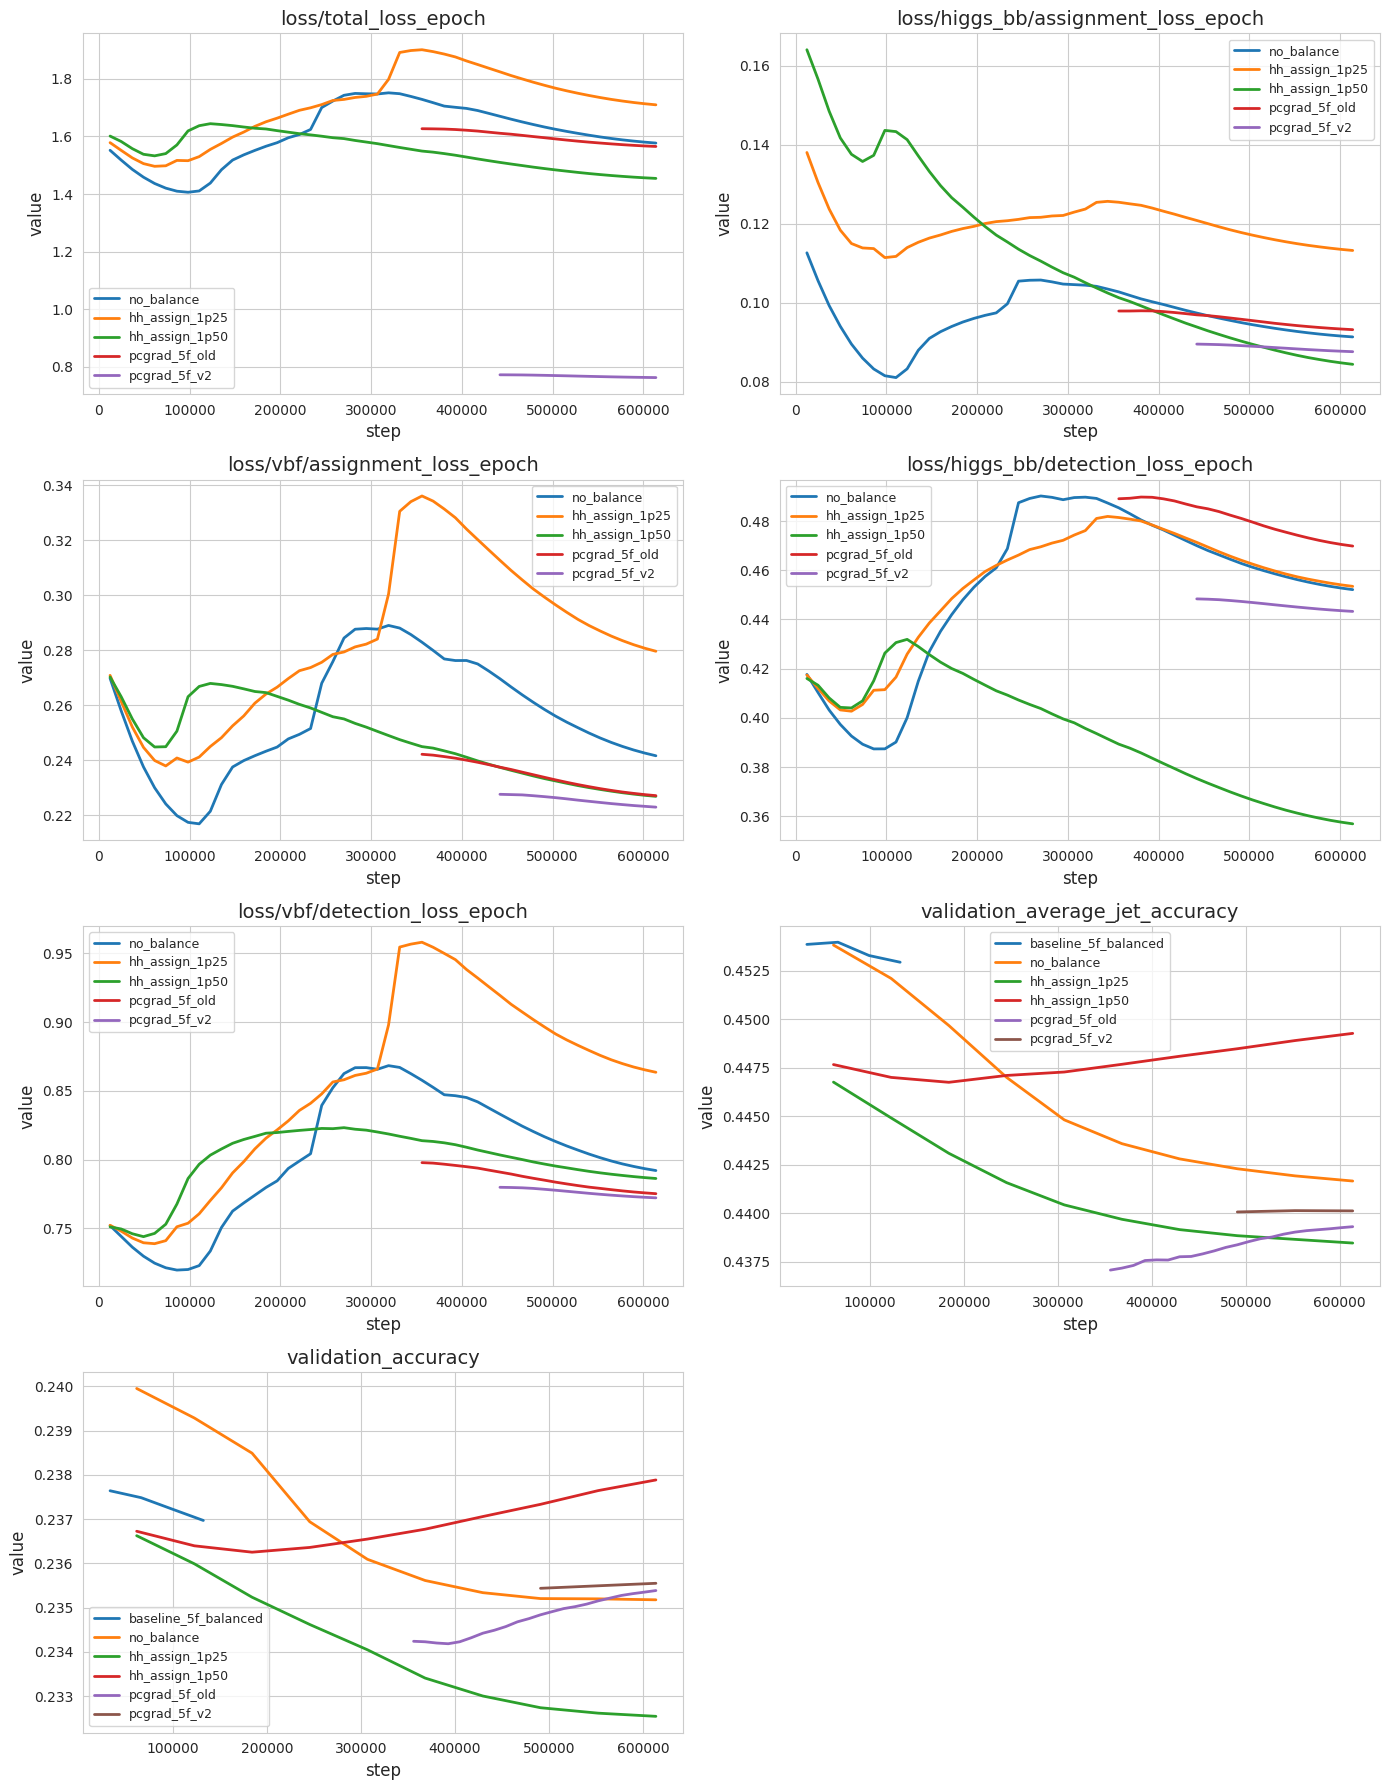

In [7]:
plot_tags = [
    'loss/total_loss_epoch',
    'loss/higgs_bb/assignment_loss_epoch',
    'loss/vbf/assignment_loss_epoch',
    'loss/higgs_bb/detection_loss_epoch',
    'loss/vbf/detection_loss_epoch',
    'validation_average_jet_accuracy',
    'validation_accuracy',
]
plot_tags = [t for t in plot_tags if t in scalars['tag'].unique()]

n = len(plot_tags)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, tag in zip(axes, plot_tags):
    sub = scalars[scalars['tag'] == tag]
    for run in RUNS:
        run_sub = sub[sub['run'] == run].sort_values('step')
        if len(run_sub) == 0:
            continue
        ax.plot(run_sub['step'], run_sub['smoothed'], label=run, linewidth=2)
    ax.set_title(tag)
    ax.set_xlabel('step')
    ax.set_ylabel('value')
    ax.legend(loc='best', fontsize=9)

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()


## Automatic loss-balance weights

These only exist for runs where `balance_losses = true`. The `no_balance` run should naturally have no `weights/*` tags.

In [8]:
if weight_tags:
    n = len(weight_tags)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, tag in zip(axes, weight_tags):
        sub = scalars[scalars['tag'] == tag]
        for run in RUNS:
            run_sub = sub[sub['run'] == run].sort_values('step')
            if len(run_sub) == 0:
                continue
            ax.plot(run_sub['step'], run_sub['smoothed'], label=run, linewidth=2)
        ax.set_title(tag)
        ax.set_xlabel('step')
        ax.set_ylabel('weight')
        ax.legend(loc='best', fontsize=9)
    for ax in axes[n:]:
        ax.axis('off')
    plt.tight_layout()
else:
    print('No automatic balance weight tags found.')


No automatic balance weight tags found.


## What to inspect

Useful questions for the weighting scan:
- Does HH assignment loss go down faster when HH is upweighted?
- Does VBF assignment loss degrade strongly when HH is upweighted?
- Does validation average jet accuracy improve or stagnate?
- In balanced runs, do the learned `weights/*` drift strongly toward the VBF-related terms?
- Is `no_balance` smoother or less noisy than the automatically balanced run?